In [1]:
#import sys, os
#sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from neural_mesh import (
    NeuralMeshModel, train, evaluate,
    extract_rule_set, gradient_rulify,
    ActivationRecorder, MeshVisualizer
)

RESOLUTION = 10
COMPLEXITY = 5
complexity_activation = 'softplus'
on_mesh_activation = 'none'
post_mesh_activation = 'none'

In [2]:
# ── reproducibility ───────────────────────────────────────────────
def set_seeds():
    SEED = 42
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

set_seeds()

In [3]:
# Dataset...

import pandas as pd
CSVFILE = 'app_inverted_pendulum/raw_inputs.csv'
df = pd.read_csv(CSVFILE, delimiter=',', encoding='utf-8')

df.head()

,user,direction,inputnum,input_outof,angledeg,angveldegsec,gravity,signaluser
0,user1,|,1,2,-60.0,-50.0,0.0,-10000000.0
1,user1,|,2,2,-60.0,-50.0,0.0,-5000000.0
2,user1,|,1,1,3.0,-20.0,0.0,-4000.0
3,user1,|,1,6,-5.0,-5.0,0.0,-500000.0
4,user1,|,2,6,-5.0,-5.0,0.0,-1000000.0


In [4]:
cols_to_use = [
    'angledeg',
    'angveldegsec',
    'signaluser'
]

input_dimnames = cols_to_use[:-1]
target_dimname = 'signaluser'

## keep the participant ID aside: it defines the groups for the split
groups_all = df['user']

## you can keep only a subset of columns if you want...
df = df[cols_to_use]

print(f"Number of rows in dataset: {len(df)}")

df.dropna(inplace=True)
groups_all = groups_all.loc[df.index]

print(f"Number of rows in final dataset wo/ NaNs: {len(df)}")
print(df.head())




Number of rows in dataset: 1950
Number of rows in final dataset wo/ NaNs: 1950
   angledeg  angveldegsec  signaluser
0     -60.0         -50.0 -10000000.0
1     -60.0         -50.0  -5000000.0
2       3.0         -20.0     -4000.0
3      -5.0          -5.0   -500000.0
4      -5.0          -5.0  -1000000.0


In [5]:
## Generic, train-fitted preprocessing:
## automatic log transform for skewed columns (decided from data, not by eye),
## followed by z-scoring.

class SkewAwarePreprocessor:
    """
    Per column (all decisions fitted on the TRAINING split only):

      1. If |skewness| > skew_threshold AND a signed-log transform
         sign(x)*log1p(|x|) actually reduces |skewness|, apply it.
         (The second check makes it safe to run on ANY column,
         including ones with negative values.)
      2. Z-score with train mean/std.

    Each per-column transform is strictly monotone increasing, so interval
    endpoints (e.g. rule antecedent ranges) can be mapped back to original
    units EXACTLY via inverse_value().
    """

    def __init__(self, skew_threshold=2.0):
        self.skew_threshold = skew_threshold

    @staticmethod
    def _slog(a):
        return np.sign(a) * np.log1p(np.abs(a))

    @staticmethod
    def _sexp(a):
        return np.sign(a) * np.expm1(np.abs(a))

    def fit(self, X_df):
        self.columns_ = list(X_df.columns)
        self.log_cols_ = []
        for c in self.columns_:
            s_raw = X_df[c].skew()
            s_log = pd.Series(self._slog(X_df[c].values)).skew()
            if abs(s_raw) > self.skew_threshold and abs(s_log) < abs(s_raw):
                self.log_cols_.append(c)
        Xt = self._logged(X_df)
        self.z_means = Xt.mean().to_numpy(copy=True)
        self.z_stds = Xt.std(ddof=0).to_numpy(copy=True)
        self.z_stds[self.z_stds < 1e-12] = 1.0   # guard: constant columns
        return self

    def _logged(self, X_df):
        Xt = X_df.copy()
        for c in self.log_cols_:
            Xt[c] = self._slog(Xt[c].values)
        return Xt

    def transform(self, X_df):
        return (self._logged(X_df) - self.z_means) / self.z_stds

    def inverse_value(self, d, v):
        """Normalized value in dimension d -> original units."""
        u = np.asarray(v, dtype=float) * self.z_stds[d] + self.z_means[d]
        if self.columns_[d] in self.log_cols_:
            u = self._sexp(u)
        return float(u)

    def report(self, X_df=None):
        print(f"Columns log-transformed (train |skew| > {self.skew_threshold}):")
        for c in self.columns_:
            mark = "LOG " if c in self.log_cols_ else "    "
            extra = f"   (skew: {X_df[c].skew():.2f})" if X_df is not None else ""
            print(f"  {mark}{c}{extra}")


In [6]:
## Separate inputs and target (raw, unnormalized)
X = df.drop(columns=[target_dimname])
y = df[target_dimname]

from sklearn.model_selection import GroupShuffleSplit
###################
###################
set_seeds()
###################
###################
## PARTICIPANT-GROUPED split: every participant's rows go to exactly ONE of
## train / validation / test, so the model is always evaluated on people it
## has never seen (a random row split puts the same person on both sides).
## Fractions refer to PARTICIPANTS (50 -> 40 / 5 / 5); row counts will vary.
tr_perc = 0.8
va_perc = 0.1
te_perc = 0.1

gss1 = GroupShuffleSplit(n_splits=1, test_size=(te_perc + va_perc), random_state=42)
tr_idx, tmp_idx = next(gss1.split(X, y, groups=groups_all))
X_train, y_train = X.iloc[tr_idx], y.iloc[tr_idx]
X_temp,  y_temp  = X.iloc[tmp_idx], y.iloc[tmp_idx]
g_temp = groups_all.iloc[tmp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=(te_perc / (te_perc + va_perc)), random_state=42)
va_idx, te_idx = next(gss2.split(X_temp, y_temp, groups=g_temp))
X_val,  y_val  = X_temp.iloc[va_idx], y_temp.iloc[va_idx]
X_test, y_test = X_temp.iloc[te_idx], y_temp.iloc[te_idx]

## sanity check: no participant appears in more than one group
u_tr = set(groups_all.loc[X_train.index]); u_va = set(groups_all.loc[X_val.index]); u_te = set(groups_all.loc[X_test.index])
assert not (u_tr & u_va) and not (u_tr & u_te) and not (u_va & u_te), "participant overlap between splits!"
print(f"participants  train/val/test: {len(u_tr)}/{len(u_va)}/{len(u_te)}")
print(f"rows          train/val/test: {len(X_train)}/{len(X_val)}/{len(X_test)}")

## Fit the preprocessor on the TRAINING split only
prep = SkewAwarePreprocessor(skew_threshold=2.0).fit(X_train)
prep.report(X_train)

## Apply the same (train-fitted) transform to all splits
X_train = prep.transform(X_train)
X_val   = prep.transform(X_val)
X_test  = prep.transform(X_test)

## NOTE: these are in TRANSFORMED (log+z) space now. Do not use them to
## denormalize log-transformed dims linearly - use prep.inverse_value().
z_means = prep.z_means
z_stds = prep.z_stds

print(X_train.head())

## ── TARGET transform (the reason v1 did not converge) ─────────────
## signaluser spans ~12 orders of magnitude: |y| goes from 0 up to 1.2e12,
## median ~10, and one single row (1.2e12) carries almost all of the variance.
## Under MSE the mesh can only chase those few outliers, so the loss sits at
## ~1e21 and R2 stays ~0; even a random forest gets R2 of -10,000 on val.
## Fix: signed log  sign(y)*log1p(|y|)  (keeps direction, compresses magnitude),
## then z-score with TRAIN statistics. y_inv() maps predictions back to
## original units. Everything downstream (mesh, rules, R2) now works in this
## transformed space.
def _slog(a): return np.sign(a) * np.log1p(np.abs(a))
def _sexp(a): return np.sign(a) * np.expm1(np.abs(a))

y_train_raw, y_val_raw, y_test_raw = y_train.copy(), y_val.copy(), y_test.copy()
y_mean = float(_slog(y_train_raw.to_numpy(dtype=float)).mean())
y_std  = float(_slog(y_train_raw.to_numpy(dtype=float)).std())

def y_fwd(v): return (_slog(np.asarray(v, dtype=float)) - y_mean) / y_std
def y_inv(v): return _sexp(np.asarray(v, dtype=float) * y_std + y_mean)

y_train = pd.Series(y_fwd(y_train_raw), index=y_train_raw.index)
y_val   = pd.Series(y_fwd(y_val_raw),   index=y_val_raw.index)
y_test  = pd.Series(y_fwd(y_test_raw),  index=y_test_raw.index)
print(f"target: raw range [{y_train_raw.min():.3g}, {y_train_raw.max():.3g}]  ->  "
      f"transformed range [{y_train.min():.2f}, {y_train.max():.2f}]")

X_train_np = X_train.to_numpy(dtype=np.float32)
y_train_np = y_train.to_numpy(dtype=np.float32)
X_val_np = X_val.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)
X_train = torch.from_numpy(X_train_np)
y_train = torch.from_numpy(y_train_np)
X_val = torch.from_numpy(X_val_np)
y_val = torch.from_numpy(y_val_np)
X_test = torch.from_numpy(X_test_np)
y_test = torch.from_numpy(y_test_np)


participants  train/val/test: 40/5/5
rows          train/val/test: 1549/169/232
Columns log-transformed (train |skew| > 2.0):
      angledeg   (skew: 0.13)
      angveldegsec   (skew: -0.04)
   angledeg  angveldegsec
0 -1.776265     -2.098357
1 -1.776265     -2.098357
2  0.190964     -0.854202
3 -0.058843     -0.232125
4 -0.058843     -0.232125
target: raw range [-9.64e+09, 1.25e+12]  ->  transformed range [-2.28, 2.67]


/var/folders/8s/3s1bzxpd0v1g7drgvt_1w6qw0000gn/T/ipykernel_10140/2486643890.py:83: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  X_train = torch.from_numpy(X_train_np)


## Before training the neural mesh, establish a baseline

In [7]:
## ── baselines: what R² is achievable on this data? ────────────────
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

set_seeds()

baselines = {
    "mean predictor": DummyRegressor(strategy="mean"),
    "linear regression": LinearRegression(),
    "random forest": RandomForestRegressor(
        n_estimators=500, min_samples_leaf=3, random_state=42
    ),
}

print(f"{'model':<20}{'R2 train':>10}{'R2 val':>10}{'R2 test':>10}")
for name, m in baselines.items():
    m.fit(X_train_np, y_train_np)
    print(f"{name:<20}"
          f"{r2_score(y_train_np, m.predict(X_train_np)):>10.4f}"
          f"{r2_score(y_val_np,   m.predict(X_val_np)):>10.4f}"
          f"{r2_score(y_test_np,  m.predict(X_test_np)):>10.4f}")

model                 R2 train    R2 val   R2 test
mean predictor          0.0000   -0.0040   -0.0006
linear regression       0.5601    0.4977    0.5249
random forest           0.8631    0.7446    0.7222


In [8]:
# ── model ─────────────────────────────────────────────────────────
## robust init ranges (ignore extreme tails) instead of raw min/max
ranges_to_explore = [
    (float(np.quantile(X_train_np[:, d], 0.01)),
     float(np.quantile(X_train_np[:, d], 0.99)))
    for d in range(X_train_np.shape[1])
]

#print(ranges_to_explore)

## hard bounds for the triangle centres = TRAINING data range per dimension.
## First/last centre are pinned to min/max, the rest move freely in between,
## so no fuzzy set can drift out of the data (which previously could make the
## mesh silently ignore an input and break rule extraction).
centre_bounds = [
    (float(X_train_np[:, d].min()), float(X_train_np[:, d].max()))
    for d in range(X_train_np.shape[1])
]

print(f"Mesh will have {COMPLEXITY ** len(ranges_to_explore):,} rules "
      f"({len(ranges_to_explore)} input dims x C={COMPLEXITY})")

set_seeds()

## ONE mesh for ALL target dimensions: the antecedent structure (triangle
## memberships + complexity cells + rules) is SHARED across outputs; only the
## per-rule output weights (mesh.s, mesh.b) are per-output. This is the
## standard MIMO TSK design and costs one training run instead of K.
## NOTE: the mesh has prod(C_d) rules — exponential in input_dim. The model
## now raises a clear ValueError (instead of killing the kernel) if that
## product exceeds max_rules; keep the feature-selection cell above in sync.
model = NeuralMeshModel(
    input_dim=len(ranges_to_explore),
    resolution=RESOLUTION,            # G = 10 fuzzy sets per dimension
    complexity=COMPLEXITY,    # C complexity cells per dimension
    num_outputs=1,    # one output neuron per target column
    task="regression",
    init_ranges=ranges_to_explore,
    complexity_activation=complexity_activation,
    on_mesh_activation=on_mesh_activation,
    post_mesh_activation=post_mesh_activation,
    # could be softplus, relu, elu, tanh, none (default is softplus)
    resolution_convex_triangles=True, # True by default
    resolution_weight_norm="thresholded_sum_to_one",
    resolution_bounds=centre_bounds,   # None = old unbounded behaviour
    # can be thresholded_sum_to_one, softmax or none (default)
)
print("")
print(model.summary(), "\n")

Mesh will have 25 rules (2 input dims x C=5)

NeuralMeshModel  task=regression  input_dim=2  outputs=1
  Resolution (G): [10, 10]  convex_triangles=True  weight_norm=thresholded_sum_to_one  bounded=yes
  Complexity (C): [5, 5]  activation=softplus
  On-mesh activation:  none
  Post-mesh activation: none
  Total rules:    25
  Learnable params: 178 



In [9]:
# ── train ─────────────────────────────────────────────────────────
set_seeds()

recorder = ActivationRecorder(
    model,
    layers=("resolution", "complexity_pre", "complexity_post", "output"),
    record_every=50,
    max_history=20,
    sample_indices=random.choices(range(X_train.shape[0]), k=5)
)

history = train(
    model, X_train, y_train,
    epochs=15000,
    batch_size=128,
    lr=0.05,
    optimiser="adam",
    print_every=500,
    X_val=X_val,
    y_val=y_val,
    recorder=recorder
)

m_tr = evaluate(model, X_train, y_train)
r2_mesh_train = 1 - m_tr['loss'] / y_train_np.var()
m_va = evaluate(model, X_val, y_val)
r2_mesh_val = 1 - m_va['loss'] / y_val_np.var()
print(f"Mesh R² train: {r2_mesh_train:.4f}   validation: {r2_mesh_val:.4f}")

Epoch    1/15000  train_loss=0.953483  RMSE=0.976465  R2=0.0700  val_loss=0.797450  val_R2=0.0816
Epoch  500/15000  train_loss=0.229276  RMSE=0.478827  R2=0.7639  val_loss=0.265722  val_R2=0.6940
Epoch 1000/15000  train_loss=0.234537  RMSE=0.484291  R2=0.7672  val_loss=0.249991  val_R2=0.7121
Epoch 1500/15000  train_loss=0.226449  RMSE=0.475867  R2=0.7548  val_loss=0.258483  val_R2=0.7023
Epoch 2000/15000  train_loss=0.245113  RMSE=0.495089  R2=0.7284  val_loss=0.289595  val_R2=0.6665
Epoch 2500/15000  train_loss=0.285119  RMSE=0.533966  R2=0.7514  val_loss=0.266103  val_R2=0.6935
Epoch 3000/15000  train_loss=0.237189  RMSE=0.487021  R2=0.7668  val_loss=0.238203  val_R2=0.7257
Epoch 3500/15000  train_loss=0.241755  RMSE=0.491686  R2=0.7624  val_loss=0.248568  val_R2=0.7137
Epoch 4000/15000  train_loss=0.237218  RMSE=0.487050  R2=0.7272  val_loss=0.298610  val_R2=0.6561
Epoch 4500/15000  train_loss=0.323672  RMSE=0.568922  R2=0.6714  val_loss=0.303105  val_R2=0.6509
Epoch 5000/15000  tr

In [10]:
# ── sanity check: do the learned triangle centres still cover the data? ──
## Centres are free parameters and can drift outside the observed range. If ALL
## centres of a dimension leave the data, that input is silently ignored by the
## mesh (its complexity activations become constant), and rule extraction will
## place antecedents where no data exist -> the rule base collapses (R2 ~ 0).
from neural_mesh.rules import _membership_geometry
for d, name in enumerate(input_dimnames):
    c, _, _ = _membership_geometry(model.memberships[d])
    c_orig = np.array([prep.inverse_value(d, v) for v in c])
    lo, hi = X_train_np[:, d].min(), X_train_np[:, d].max()
    lo_o, hi_o = prep.inverse_value(d, lo), prep.inverse_value(d, hi)
    tol = 1e-4 * (hi_o - lo_o)   # float round-off at the pinned end centres
    inside = ((c_orig >= lo_o - tol) & (c_orig <= hi_o + tol)).sum()
    with torch.no_grad():
        mu = model.memberships[d](torch.from_numpy(X_train_np[:, d]))
    uncovered = (mu.sum(1) < 1e-6).float().mean().item()
    print(f"{name}: centres {np.round(c_orig, 1)}")
    print(f"   data range [{lo_o:.1f}, {hi_o:.1f}]  centres inside: {inside}/{len(c)}  "
          f"training rows with zero membership: {uncovered:.1%}")
    if inside == 0 or uncovered > 0.05:
        print(f"   WARNING: '{name}' is (partly) not represented by the mesh -- "
              f"re-run with another seed / fewer epochs before extracting rules.")


angledeg: centres [-60.  -53.2 -42.9  -3.5  12.   13.3  14.6  30.8  47.5  60. ]
   data range [-60.0, 60.0]  centres inside: 10/10  training rows with zero membership: 0.0%
angveldegsec: centres [-50.  -45.2 -35.8 -19.8  -4.5   1.6  15.1  29.3  30.   50. ]
   data range [-50.0, 50.0]  centres inside: 10/10  training rows with zero membership: 0.0%


## Let's derive the rules and optimize them

In [11]:
initial_rules = extract_rule_set(model, X_train)

print(f"Extracted {len(initial_rules.rules)} rules\n")
#print(initial_rules.sorted(method="weights"))

Extracted 25 rules



In [12]:
data = np.column_stack([X_train_np, y_train_np])

set_seeds()

result = None
for result in gradient_rulify(
    data=data,
    initial_rule_set=initial_rules,
    num_iterations=300,          # 80 is nowhere near enough; cosine LR schedule
                              # also decays instantly over 80 steps
    learning_rate=0.03,
    weight_sparsity_lambda=0.005, # gentler: with thousands of rules, 0.02·Σw
                              # crushes all weights uniformly
    ant_overlap_lambda=0.1,
    sigma_reg_lambda=0.01,
    fitness_fn="R2Rulescard",
    rulescard_lambda=0.1,
    prune_every=50,              # let weights differentiate before culling
    prune_threshold=0.1 / len(initial_rules.rules),   # scale to 1/R, not absolute
    yield_every=10,
):
    pass

print(result)
print(f"\nRules after pruning: {len(result.to_rule_set().rules)}")

[#####-------------------------] 50/300  Rule opt (best: 0.7055, rules: 25, active: 15)
  [Prune @ iter 50] 25 → 15 rules (removed 10, total removed: 10)
[##########--------------------] 100/300  Rule opt (best: 0.6771, rules: 15, active: 13)
  [Prune @ iter 100] 15 → 13 rules (removed 2, total removed: 12)
[##############################] 300/300  Rule opt (best: 0.6882, rules: 13, active: 13)

Rule optimisation complete.  Best fitness: 0.688204 (iteration 300), final rules: 13
Iteration 300: fitness = 0.688204 (R2 = 0.7882; active_rules = 13.0000; total_rules = 13.0000); 13 active rules

Rules after pruning: 13


In [13]:
# Inference through the original rule model
pred = result.infer(X_train_np)
r2 = 1 - ((y_train_np - pred[:, 0])**2).sum() / ((y_train_np - y_train_np.mean())**2).sum()
print(f"Rule-set R² (train): {r2:.4f}")

pred_val = result.infer(X_val_np)
r2_val = 1 - ((y_val_np - pred_val[:, 0])**2).sum() / ((y_val_np - y_val_np.mean())**2).sum()
print(f"Rule-set R² (validation):  {r2_val:.4f}")

Rule-set R² (train): 0.7882
Rule-set R² (validation):  0.7329


In [14]:
merged_rs = result.merge_rules(n_target=10, verbose=True)
# Optional: max_consequent_gap=0.5 prevents merging rules with very different outputs

result2 = None
for result2 in gradient_rulify(
    data=data,
    initial_rule_set=merged_rs,
    num_iterations=6000,
    learning_rate=0.03,
    weight_sparsity_lambda=0.002,
    ant_overlap_lambda=0.1,
    sigma_reg_lambda=0.01,
    yield_every=200,
):
    pass

print(result2)

Merged 13 rules → 10 rules.  Antecedent ranges per dim: [3, 8]
[##############################] 6000/6000  Rule opt (best: 0.7969, rules: 10, active: 7))

Rule optimisation complete.  Best fitness: 0.796865 (iteration 6000), final rules: 10
Iteration 6000: fitness = 0.796865 (R2 = 0.7969; active_rules = 7.0000; total_rules = 10.0000); 10 active rules


In [15]:
# Inference through the optimised Gaussian rule model
pred = result2.infer(X_train_np)
r2 = 1 - ((y_train_np - pred[:, 0])**2).sum() / ((y_train_np - y_train_np.mean())**2).sum()
print(f"Rule-set R² (train): {r2:.4f}")

pred_val = result2.infer(X_val_np)
r2_val = 1 - ((y_val_np - pred_val[:, 0])**2).sum() / ((y_val_np - y_val_np.mean())**2).sum()
print(f"Rule-set R² (validation):  {r2_val:.4f}")

Rule-set R² (train): 0.7969
Rule-set R² (validation):  0.7455


In [16]:
# Export as a standard RuleSet (usable with infer_from_ruleset / to_csv)
final_rules = result2.to_rule_set()
print(final_rules.sorted(method="consequents"))
# final_rules.to_csv(min_weight=0.0, filename="mesh_rules.csv")

2 AND 7 => 2.51 (representativeness weight: 0.0151)
1 AND 5 => 1.12 (representativeness weight: 0.0350)
2 AND 4 => 0.93 (representativeness weight: 0.2342)
1 AND 3 => 0.80 (representativeness weight: 0.0014)
0 AND 6 => 0.65 (representativeness weight: 0.0020)
1 AND 2 => 0.64 (representativeness weight: 0.0001)
2 AND 2 => -0.84 (representativeness weight: 0.0463)
1 AND 1 => -1.00 (representativeness weight: 0.3794)
0 AND 0 => -1.20 (representativeness weight: 0.2859)
2 AND 1 => -3.90 (representativeness weight: 0.0006)

Total number of rules: 10

Total representation: 0.9999999999999999


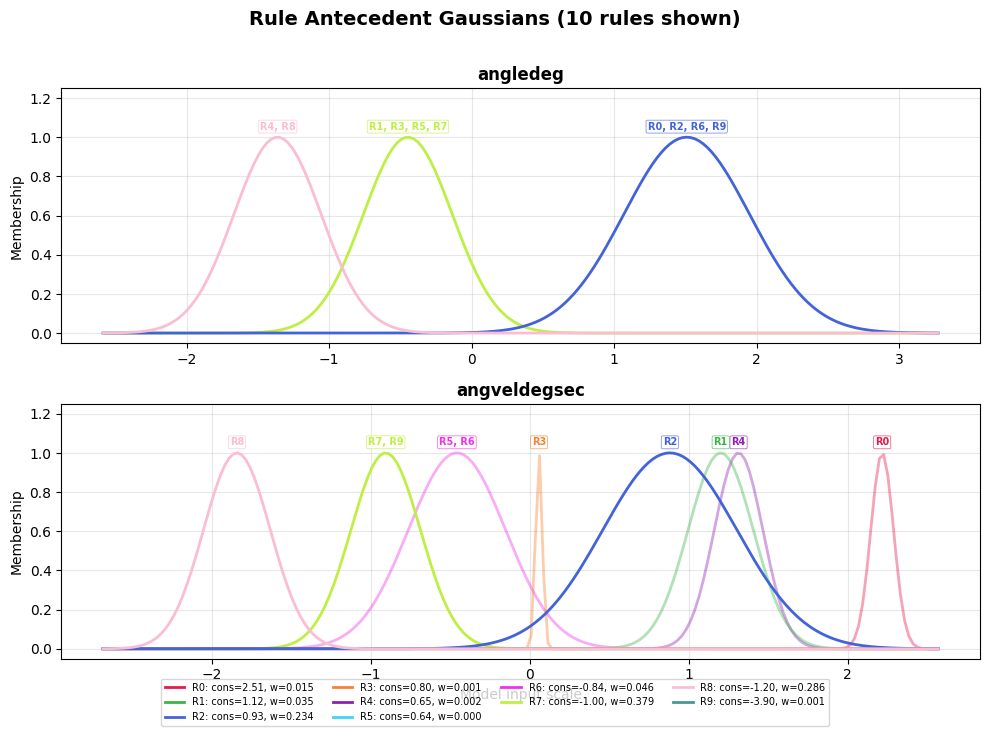

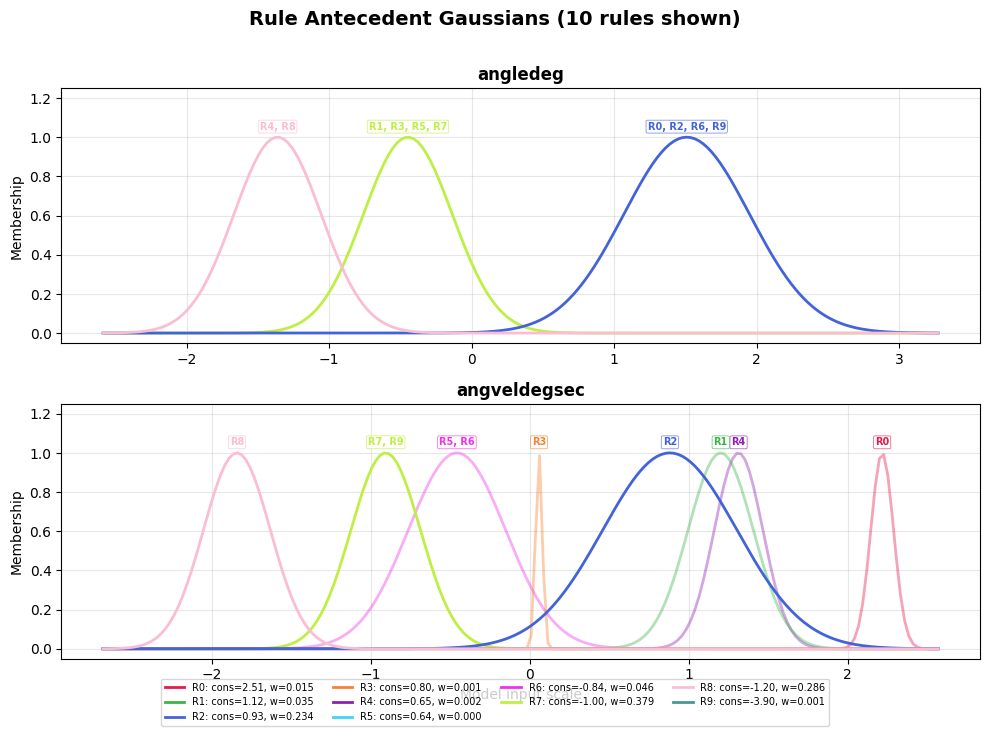

In [17]:
## Plot in normalized (transformed) space.
## NOTE: do NOT pass z_means/z_stds here - that linear denormalization is
## only valid when no column was log-transformed. Original-unit ranges are
## printed in the next cell instead.
result2.plot_rules(
    dim_names=[
        nm + (" [log]" if nm in prep.log_cols_ else "")
        for nm in input_dimnames
    ],
    min_weight=0.0,
)


In [18]:
## Antecedent ranges of the final rules, mapped back to ORIGINAL units.
## The signed-log + z-score transform is monotone per column, so range
## endpoints invert exactly. (The Gaussian *shape* only exists in the
## transformed space - a range is the honest original-scale statement.)
print("Antecedent ranges in original units:\n")
for d, ranges in enumerate(final_rules.antecedent_ranges):
    tag = "  (log-scaled dim)" if input_dimnames[d] in prep.log_cols_ else ""
    print(f"{input_dimnames[d]}{tag}:")
    for k, (lo, hi) in enumerate(ranges):
        print(f"   antecedent {k}: "
              f"[{prep.inverse_value(d, lo):.4g}, {prep.inverse_value(d, hi):.4g}]")
    print()


Antecedent ranges in original units:

angledeg:
   antecedent 0: [-66.33, -27.11]
   antecedent 1: [-37.41, 2.544]
   antecedent 2: [16.96, 73.49]

angveldegsec:
   antecedent 0: [-53.98, -33.68]
   antecedent 1: [-31.81, -10.71]
   antecedent 2: [-25.22, 4.307]
   antecedent 3: [0.9641, 3.015]
   antecedent 4: [1.487, 42.2]
   antecedent 5: [19.65, 39.47]
   antecedent 6: [24.89, 39.64]
   antecedent 7: [50.6, 57.51]



## Use this helper to describe the rules

In [19]:
def describe_rules(result, prep, dim_names, X_train_np,
                   min_weight=0.02, dontcare_sigma=1.5, sigma_mult=2.0):
    """Linguistic rendering: skips near-dead rules and 'don't care' antecedents
    (Gaussians so wide they cover essentially all data in that z-scored dim)."""
    w = result._weights / result._weights.sum()
    order = np.argsort(-result._consequents)
    for rank, r in enumerate(order):
        if w[r] < min_weight:
            continue
        conds = []
        for d in range(len(dim_names)):
            k = int(result._ant_idx[r, d])
            c = float(result._ant_centers[d][k])
            s = float(result._ant_sigmas[d][k])
            if s > dontcare_sigma:          # covers the whole dim -> irrelevant
                continue
            pct = (X_train_np[:, d] < c).mean()
            label = ("very low" if pct < 0.10 else "low" if pct < 0.35 else
                     "very high" if pct > 0.90 else "high" if pct > 0.65 else
                     "mid-range")
            lo = prep.inverse_value(d, c - sigma_mult * s)
            hi = prep.inverse_value(d, c + sigma_mult * s)
            conds.append(f"{dim_names[d]} is {label} [{lo:.3g} .. {hi:.3g}]")
        body = " AND ".join(conds) if conds else "(no specific conditions)"
        print(f"IF {body}\n   THEN signal ≈ {float(y_inv(result._consequents[r])):.3g}"
              f"   (transformed: {result._consequents[r]:.2f})"
              f"   (weight {w[r]:.2f})\n")

describe_rules(result2, prep, input_dimnames, X_train_np)

IF angledeg is low [-37.4 .. 2.54] AND angveldegsec is high [19.6 .. 39.5]
   THEN signal ≈ 1.63e+05   (transformed: 1.12)   (weight 0.04)

IF angledeg is very high [17 .. 73.5] AND angveldegsec is high [1.49 .. 42.2]
   THEN signal ≈ 2.26e+04   (transformed: 0.93)   (weight 0.23)

IF angledeg is very high [17 .. 73.5] AND angveldegsec is low [-25.2 .. 4.31]
   THEN signal ≈ -3.56e+03   (transformed: -0.84)   (weight 0.05)

IF angledeg is low [-37.4 .. 2.54] AND angveldegsec is low [-31.8 .. -10.7]
   THEN signal ≈ -1.92e+04   (transformed: -1.00)   (weight 0.38)

IF angledeg is low [-66.3 .. -27.1] AND angveldegsec is very low [-54 .. -33.7]
   THEN signal ≈ -1.43e+05   (transformed: -1.20)   (weight 0.29)



In [20]:
viz = MeshVisualizer(recorder)

# See which epochs were recorded
print(recorder.epochs)  # e.g. [50, 100, 150, 200, 250, 300]

[14050, 14100, 14150, 14200, 14250, 14300, 14350, 14400, 14450, 14500, 14550, 14600, 14650, 14700, 14750, 14800, 14850, 14900, 14950, 15000]


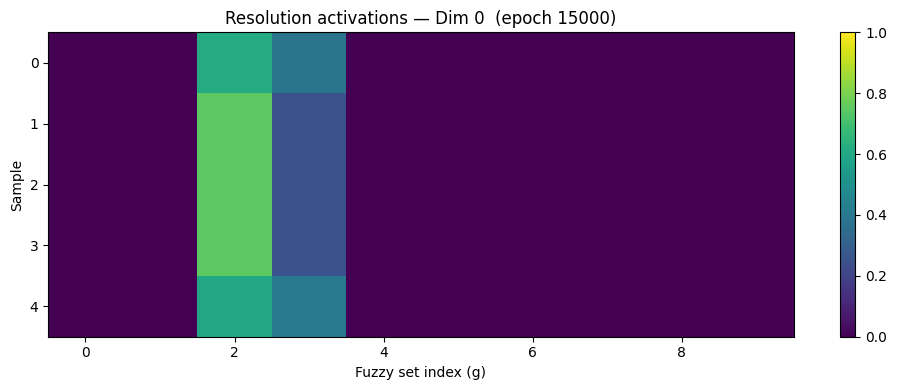

<Axes: title={'center': 'Resolution activations — Dim 0  (epoch 15000)'}, xlabel='Fuzzy set index (g)', ylabel='Sample'>

In [21]:
# Plot a specific epoch
viz.plot_resolution(dim=0, epoch=15000)

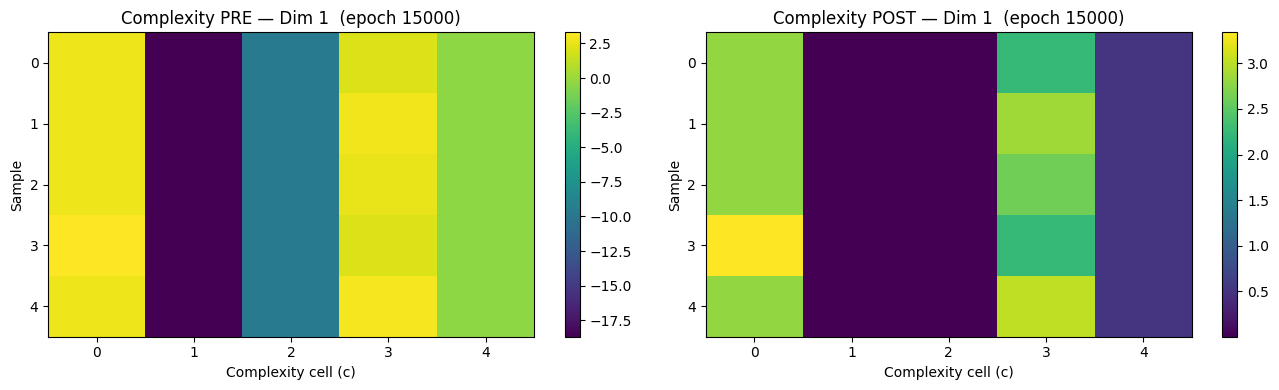

[<Axes: title={'center': 'Complexity PRE — Dim 1  (epoch 15000)'}, xlabel='Complexity cell (c)', ylabel='Sample'>,
 <Axes: title={'center': 'Complexity POST — Dim 1  (epoch 15000)'}, xlabel='Complexity cell (c)', ylabel='Sample'>]

In [22]:
viz.plot_complexity(dim=1, epoch=15000, show_pre=True)

In [ ]:
#viz.plot_all(epoch=300)

In [ ]:
viz.plot_activation_over_time("complexity_post", dim=0, sample=0)

In [ ]:
# Full (C×G) weight matrix as a heatmap with annotated values
viz.plot_complexity_weights(dim=1)

In [ ]:
# Bar chart for a single resolution cell → all complexity cells
viz.plot_complexity_weights(dim=1, resolution_cell=3)

In [ ]:
# Show raw weights before normalization for comparison
viz.plot_complexity_weights(dim=1, resolution_cell=3, show_effective=False)

In [ ]:
# Compare two epochs side by side
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
#viz.plot_resolution(dim=0, epoch=50, ax=ax1, show=False)
#viz.plot_resolution(dim=0, epoch=300, ax=ax2, show=False)
#plt.show()

In [23]:
# ── evaluate ──────────────────────────────────────────────────────
metrics = evaluate(model, X_test, y_test)
print(f"\nFinal test RMSE: {metrics['rmse']:.6f}")

# Quick sanity check on a few samples
preds = model.predict(X_test[:5])
print("\nSample predictions vs ground truth:")
for i in range(5):
    print(f"  x={X_test_np[i].round(3)}  pred={preds[i].item():.4f}  "
          f"true={y_test_np[i]:.4f}   "
          f"[original units: pred={float(y_inv(preds[i].item())):.3g}  "
          f"true={y_test_raw.iloc[i]:.3g}]")


Final test RMSE: 0.415062

Sample predictions vs ground truth:
  x=[-1.152 -1.476]  pred=-1.0979  true=-0.8034   [original units: pred=-5.17e+04  true=-2.5e+03]
  x=[-1.152 -1.476]  pred=-1.0979  true=-1.4751   [original units: pred=-5.17e+04  true=-2.5e+06]
  x=[-1.152 -1.476]  pred=-1.0979  true=-1.5425   [original units: pred=-5.17e+04  true=-5e+06]
  x=[-1.152 -1.476]  pred=-1.0979  true=-1.6099   [original units: pred=-5.17e+04  true=-1e+07]
  x=[-1.152 -1.476]  pred=-1.0979  true=-1.2472   [original units: pred=-5.17e+04  true=-2.4e+05]


In [24]:
# Inference through the optimised Gaussian rule model
pred = result2.infer(X_train_np)
r2 = 1 - ((y_train_np - pred[:, 0])**2).sum() / ((y_train_np - y_train_np.mean())**2).sum()
print(f"Rule-set R² (train): {r2:.4f}")

pred_val = result2.infer(X_val_np)
r2_val = 1 - ((y_val_np - pred_val[:, 0])**2).sum() / ((y_val_np - y_val_np.mean())**2).sum()
print(f"Rule-set R² (validation):  {r2_val:.4f}")

pred_test = result2.infer(X_test_np)
r2_test = 1 - ((y_test_np - pred_test[:, 0])**2).sum() / ((y_test_np - y_test_np.mean())**2).sum()
print(f"Rule-set R² (test):  {r2_test:.4f}")

Rule-set R² (train): 0.7969
Rule-set R² (validation):  0.7455
Rule-set R² (test):  0.7243
